### Part 0: Imports

In [4]:
from scipy.io import arff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

### Part 1: Data Loading, Preprocessing & Overview

In [5]:
data, meta = arff.loadarff('adult.arff')
df = pd.DataFrame(data)

# Identify and decode byte string columns due to ARFF loading
for col in df.columns:
    # Check if the column data type is 'object' and contains byte strings
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.decode('utf-8')
        except AttributeError:
            # Handle cases where some 'object' columns might not be byte strings
            pass

# Replace '?' character with NaN and drop rows with missing values
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Overview the dataset
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             45222 non-null  float64
 1   workclass       45222 non-null  object 
 2   fnlwgt          45222 non-null  float64
 3   education       45222 non-null  object 
 4   education-num   45222 non-null  float64
 5   marital-status  45222 non-null  object 
 6   occupation      45222 non-null  object 
 7   relationship    45222 non-null  object 
 8   race            45222 non-null  object 
 9   sex             45222 non-null  object 
 10  capital-gain    45222 non-null  float64
 11  capital-loss    45222 non-null  float64
 12  hours-per-week  45222 non-null  float64
 13  native-country  45222 non-null  object 
 14  class           45222 non-null  object 
dtypes: float64(6), object(9)
memory usage: 5.5+ MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K
5,34.0,Private,198693.0,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States,<=50K


In [ ]:
# Encode categorical features using LabelEncoder

# Map categories to 0 and 1
df['workclass'] = LabelEncoder().fit_transform(df['workclass'])
df['education'] = LabelEncoder().fit_transform(df['education'])
df['occupation'] = LabelEncoder().fit_transform(df['occupation'])
df['relationship'] = LabelEncoder().fit_transform(df['relationship'])
df['race'] = LabelEncoder().fit_transform(df['race'])
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['native-country'] = LabelEncoder().fit_transform(df['native-country'])
df['class'] = LabelEncoder().fit_transform(df['class'])
df['marital-status'] = LabelEncoder().fit_transform(df['marital-status'])

df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             45222 non-null  float64
 1   workclass       45222 non-null  int64  
 2   fnlwgt          45222 non-null  float64
 3   education       45222 non-null  int64  
 4   education-num   45222 non-null  float64
 5   marital-status  45222 non-null  int64  
 6   occupation      45222 non-null  int64  
 7   relationship    45222 non-null  int64  
 8   race            45222 non-null  int64  
 9   sex             45222 non-null  int64  
 10  capital-gain    45222 non-null  float64
 11  capital-loss    45222 non-null  float64
 12  hours-per-week  45222 non-null  float64
 13  native-country  45222 non-null  int64  
 14  class           45222 non-null  int64  
dtypes: float64(6), int64(9)
memory usage: 5.5 MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,2,226802.0,1,7.0,4,6,3,2,1,0.0,0.0,40.0,38,0
1,38.0,2,89814.0,11,9.0,2,4,0,4,1,0.0,0.0,50.0,38,0
2,28.0,1,336951.0,7,12.0,2,10,0,4,1,0.0,0.0,40.0,38,1
3,44.0,2,160323.0,15,10.0,2,6,0,2,1,7688.0,0.0,40.0,38,1
5,34.0,2,198693.0,0,6.0,4,7,1,4,1,0.0,0.0,30.0,38,0


### Part 2: Exploratory Data Analysis (EDA)

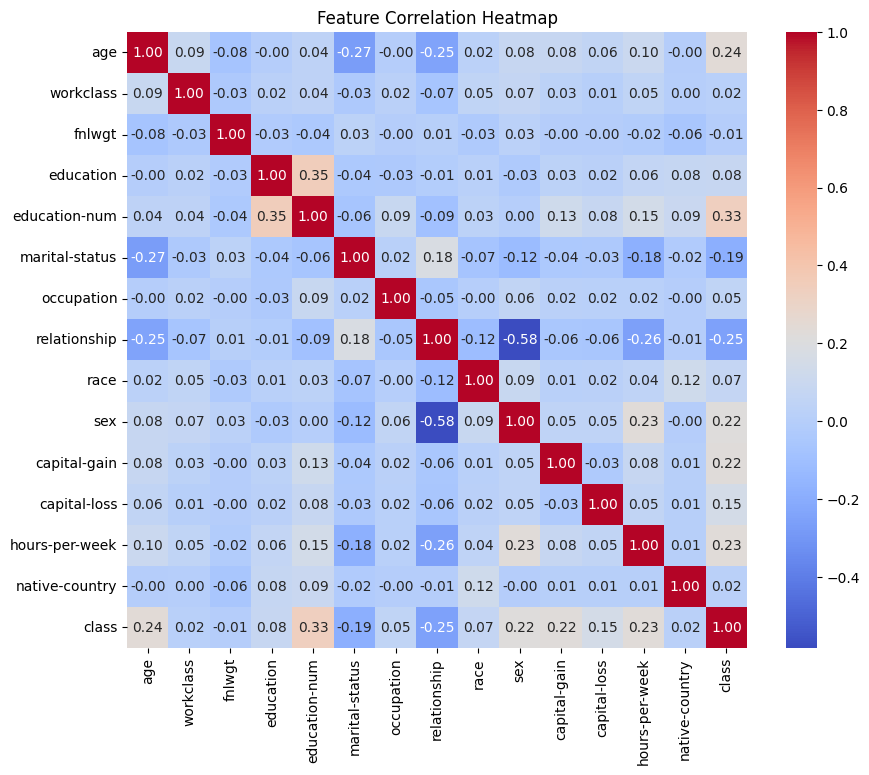

In [ ]:
# Feature correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Feature Correlation Heatmap')
plt.show()

# Strong positive correlation with class: relationship (0.46), marital-status
# Strong negative correlation with class: education (-0.31), occupation (-0.28), native-country (-0.19)

### Part 3: Training and Test Data Definition

In [ ]:
X, y = df.drop('class', axis=1), df['class']

# Split Data (training data 80%, testing data 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Part 4: Model Training

In [42]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Part 5: Model Evaluation

In [43]:
# Evaluate the model
y_pred = model.predict(X_test_scaled)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89      6803
           1       0.71      0.45      0.55      2242

    accuracy                           0.82      9045
   macro avg       0.77      0.69      0.72      9045
weighted avg       0.81      0.82      0.80      9045

Confusion Matrix:
 [[6388  415]
 [1238 1004]]
